# 基于查普曼循环的大气臭氧浓度垂直分布建模

## 查普曼循环的微观物理化学机制

1930 年, 英国地球物理学家西德尼·查普曼 (Sydney Chapman) 首次提出了一套纯气相的光化学动力学模型, 试图从微观的物理化学角度解释平流层中臭氧层的形成与维持机制. 这套后来被命名为“查普曼循环” (Chapman Cycle) 的经典理论体系, 仅仅使用了四个极其简洁的基本反应, 便极其优美地勾勒出了大气平流层中氧气 ($\mathrm{O}_2$)、臭氧 ($\mathrm{O}_3$) 和高活性氧原子 ($\mathrm{O}$) 之间在太阳紫外辐射驱动下相互转化的动态平衡图景. 

在这个极其精妙的自然防御系统中, 包含了光子能量与化学键能的激烈博弈, 以及宏观热力学与微观碰撞概率的完美交汇. 整个循环由两个生成奇氧 ($\mathrm{O}$ 和 $\mathrm{O}_3$) 的步骤与两个消耗奇氧的步骤共同闭环. 以下是对这四大核心物理化学动力学过程的逐一剖析:

### 光解反应 (产生氧原子)

$$
\ce{O2}+ h\nu \xrightarrow{J_1} {2O}
$$

氧气分子 ($\mathrm{O}_2$) 的 O=O 双键键能约为 $498 \text{ kJ/mol}$, 即断裂一摩尔氧气分子 ($6.022 \times 10^{23}$ 个分子) 中的双键所需的总能量为 $498000\text{ J}$. 因此, 断裂单个氧气分子双键所需要的能量 $E$ 为:

$$
E = \frac{498000}{6.022 \times 10^{23}} \approx 8.27 \times 10^{-19} \text{ J}
$$

根据普朗克-爱因斯坦关系式 $E=h\nu$, 单个光子所携带的能量 $E$ 与光子频率 $\nu$ 成正比, 比例系数为普朗克常数 $h \approx 6.626 \times 10^{-34} \text{ J·s}$. 因此, 能够断裂 O=O 双键的光子所具备的能量必须满足 $h\nu > 8.27 \times 10^{-19}\text{ J}$, 解得临界频率 $\nu > 1.248 \times 10^{15}\text{ Hz}$. 利用波速公式 $c = \lambda\nu$ (其中光速 $c \approx 3.0 \times 10^8 \text{ m/s}$), 最终得到触发该反应的临界波长:

$$
\lambda < 2.40 \times 10^{-7} \text{ m} = 240 \text{ nm}
$$

太阳辐射的短波紫外线 (UV-C, 标准波段为 100-280 nm) 中, 只有波长小于 240 nm 的高能部分才能满足上述条件, 触发氧气的光解. 当这部分致命的高能紫外线自上而下穿透地球大气层时, 会被高层大气的气体分子 (主要是 $\mathrm{O}_2$) 强烈吸收. 这种吸收作用导致能够引发裂解的有效光子数量随海拔高度的下降而呈指数级骤减. 因此, 这一光解反应主要发生在大气层的中上部 (平流层中上部及中间层).

在反应动力学中, 箭头上方的 $J_1$ 称为**光解速率常数** (Photolysis Rate Constant) 或光化学频率 (Photochemical Frequency), 单位是 $\text{s}^{-1}$. 这是一个准一级反应速率常数, 它代表的物理意义是: 在特定高度的光照环境下, 单个氧气分子 ($\mathrm{O}_2$) 在一秒钟内被高能紫外线光子击中并发生断键裂解的概率. 

需要特别注意的是, 在大气光化学中, 气体物质的浓度通常不再使用传统的体积摩尔浓度 (mol/L), 而是采用“数密度” (Number Density) 来表示, 即单位体积内的分子个数, 单位通常为 $\text{cm}^{-3}$ (个/立方厘米). 因此, 整个光解反应在单位体积内的宏观消耗速率 $v_1$ (单位为 $\text{cm}^{-3} \cdot \text{s}^{-1}$) 可以表达为: 

$$
v_1 = J_1 \cdot [\mathrm{O}_2]
$$

这项速率表达式将是我们后续建立化学稳态方程不可或缺的基础.

由于 $J_1$ 的大小直接取决于环境中具备足够能量的光子通量, 而在地球大气层中, 该通量由于沿途上方气体的强烈吸收, 随海拔高度 ($z$) 的下降而急剧衰减. 因此, 大气模型中的 $J_1$ 是一个高度依赖于海拔 $z$ 的变量. 本文在后续的稳态近似计算中, 将直接采用前人基于标准大气模型计算出的 $J_1$ 随高度变化的廓线数据.

### 合成反应 (产生臭氧)

$$
\ce{O + O2 + M} \xrightarrow{k_2} \ce{O3 + M}
$$

在光解反应中产生的高活性氧原子 ($\mathrm{O}$) 会迅速与周围丰富的氧气分子 ($\mathrm{O}_2$) 结合. 然而, 这是一个典型的三体反应 (Termolecular Reaction), 方程式中的 $\mathrm{M}$ 被称为“第三体” (通常是大气中大量存在的 $\mathrm{N}_2$ 或 $\mathrm{O}_2$ 分子). 

引入第三体 $\mathrm{M}$ 是微观物理中动量与能量守恒的必然要求. 当 $\mathrm{O}$ 与 $\mathrm{O}_2$ 碰撞结合时, 会释放出大量的化学成键能, 形成一个能量极高且极不稳定的过渡态分子 ($\mathrm{O}_3^*$). 如果没有其他粒子介入, 这个富能的 $\mathrm{O}_3^*$ 无法单独通过辐射光子等方式在极短的时间内排散掉多余的能量. 这一“无效碰撞”过程可直观地表示为: 

$$
\mathrm{O} + \mathrm{O}_2 \rightarrow \mathrm{O}_3^* \rightarrow \mathrm{O} + \mathrm{O}_2
$$

该方程式深刻地揭示了: 在没有第三体的情况下, $\mathrm{O}_3^*$ 会瞬间重新裂解为最初的反应物, 导致整个碰撞过程等同于什么都没有发生, 无法实现臭氧的净生成. 

此时, 必须有第三个分子 $\mathrm{M}$ 在极短的时间窗口内参与碰撞. $\mathrm{M}$ 作为一个惰性的‘能量汇’ (Energy Sink), 与 $\mathrm{O}_3^*$ 发生**非弹性碰撞**. 在严格遵守总动量守恒的前提下, $\mathrm{O}_3^*$ 内部剧烈的振动能被转移, 转化为碰撞后分子系统宏观的平动动能 (即发生 V-T 能量转移). 这种分子平均平动动能的激增, 在宏观热力学上便表现为平流层大气的显著升温现象. 只有被 $\mathrm{M}$ 带走多余能量后, 臭氧分子 ($\mathrm{O}_3$) 才能真正稳定存在. 

该反应的三分子动力学速率方程式可表达为: 

$$
v_2 = k_2 \cdot [\mathrm{O}] \cdot [\mathrm{O}_2] \cdot [\mathrm{M}]
$$

其中, $k_2$ 为该三体反应的速率常数 (单位通常为 $\text{cm}^6 \cdot \text{s}^{-1}$), $v_2$ 代表单位时间、单位体积内生成 $\mathrm{O}_3$ 的宏观速率. 值得注意的是, 在地球大气层中, 空气数密度 $[\mathrm{M}]$ 和氧气数密度 $[\mathrm{O}_2]$ 均服从流体静力学平衡, 随海拔高度 $z$ 的增加而呈指数级递减, 这将深刻影响不同高度带的臭氧合成效率.

### 光解反应 (消耗臭氧)

$$
\ce{O3} + h\nu \xrightarrow{J_3} \ce{O2} + \ce{O}
$$

从结构化学的角度来看, 臭氧 ($\mathrm{O}_3$) 存在共振杂化现象, 其氧氧键的平均键级约为 1.5, 这使得其分子骨架本就比拥有纯双键 (键级为 2.0) 的氧气 ($\mathrm{O}_2$) 更为脆弱. 

更为关键的是, 根据光化学中的自旋守恒规则, 单重态的 $\mathrm{O}_3$ 吸收光子发生裂解时, 必须生成处于激发态的单重态氧分子 $\mathrm{O}_2(a^1\Delta_g)$ 和激发态氧原子 $\mathrm{O}(^1D)$. 这一特定量子光解途径所需的总能量约为 $374 \text{ kJ/mol}$. 与第一步光解 $\mathrm{O}_2$ 的推导逻辑类似, 断裂单个 $\mathrm{O}_3$ 分子所需的能量 $E$ 为:

$$
E = \frac{374000}{6.022 \times 10^{23}} \approx 6.21 \times 10^{-19} \text{ J}
$$

根据普朗克-爱因斯坦关系式 $E=h\nu$ 与波速公式 $c=\lambda\nu$, 可求得触发该反应的临界波长:

$$
\lambda \approx \frac{6.626 \times 10^{-34} \times 3.0 \times 10^8}{6.21 \times 10^{-19}} \approx 3.20 \times 10^{-7} \text{ m} = 320 \text{ nm}
$$

这一严密的物理化学计算表明: 臭氧光解的波长阈值大幅放宽至 320 nm. 这意味着, 除了极高能的 UV-C 之外, 太阳辐射中波长在 240 nm 到 320 nm 之间的中波紫外线 (主要是对生物极具杀伤力的 UV-B 波段) 也能轻易将臭氧击碎 (对应著名的 Hartley 吸收带). 这正是臭氧层能够成功为地球表面屏蔽绝大部分 UV-B 辐射的微观物理机制.

在动力学表达上, 该反应的宏观消耗速率 $v_3$ (单位为 $\text{cm}^{-3} \cdot \text{s}^{-1}$) 为:

$$
v_3 = J_3 \cdot [\mathrm{O}_3]
$$

式中的 $J_3$ 为臭氧的光解速率常数 (单位 $\text{s}^{-1}$). 由于较长波长的 UV-B 大气穿透能力远强于 UV-C, 因此在平流层中下部 (例如 15-20 km 高度), 当导致 $\mathrm{O}_2$ 光解的 $J_1$ 已经衰减近乎为零时, 导致 $\mathrm{O}_3$ 光解的 $J_3$ 依然保持着可观的数值. 这种 $J_1$ 与 $J_3$ 随高度衰减的“非同步性”, 是在稳态模型中塑造平流层臭氧浓度峰值的核心数学诱因.

### 复合反应 (消耗臭氧)

$$
\ce{O} + \ce{O3} \xrightarrow{k_4} \ce{2O2}
$$

这是查普曼循环的最后一步. 需要强调的是, 整个查普曼循环完全基于纯气相 (均相) 反应体系构建, 而这一步正是该体系下臭氧的“自然死亡”过程. 在经历前三步光解与合成的剧烈内部循环后, 高活性的氧原子 ($\mathrm{O}$) 与臭氧分子 ($\mathrm{O}_3$) 发生双分子碰撞, 重新结合为最稳定、基态的氧气分子 ($\mathrm{O}_2$). 这一步是整个循环中唯一真正将“奇氧” (Odd Oxygen, 即 $\mathrm{O}$ 和 $\mathrm{O}_3$) 彻底移出系统, 并将其逆向转化为“偶氧” ($\mathrm{O}_2$) 的终结步骤.

在动力学上, 该反应的宏观消耗速率 $v_4$ (单位为 $\text{cm}^{-3} \cdot \text{s}^{-1}$) 表达为:

$$
v_4 = k_4 \cdot [\mathrm{O}] \cdot [\mathrm{O}_3]
$$

式中的 $k_4$ 为该双分子反应的速率常数 (单位为 $\text{cm}^3 \cdot \text{s}^{-1}$). 与直接受紫外线光子通量衰减驱动的光解速率常数 ($J$) 不同, $k_4$ 纯粹受宏观热力学控制, 遵循阿伦尼乌斯公式 (Arrhenius equation), 表现为大气环境绝对温度 $T$ 的函数. 极其关键的是, 由于地球大气温度 $T$ 本身随海拔高度 $z$ 呈现出复杂的垂直分布 (即存在温度廓线 $T(z)$), 这种热力学传递使得 $k_4$ 在实际的大气模型中同样是一个高度依赖于 $z$ 的变量. 尽管这一复合反应的发生概率远低于前述的光解与合成, 但它作为终极的“消耗阀门”, 从根本上制约了平流层臭氧浓度的理论上限.

### 稳态近似分析与臭氧浓度推导

在进行严密的数学方程推导之前, 我们必须先建立起这四个核心反应在大气空间中的物理直觉. 真实平流层中的 $v_1, v_2, v_3, v_4$ 并非处于同一数量级, 且它们发生的最剧烈位置 (峰值高度) 也各不相同. 这种在数值与空间上的巨大差异, 正是“快慢循环”理论的核心:

1. 数量级上的天壤之别 (快循环 vs 慢速阀门)

反应 2 (合成 $\mathrm{O}_3$) 和反应 3 (光解 $\mathrm{O}_3$) 构成了奇氧 ($\mathrm{O}_x$) 家族内部极其迅猛的相互转化, 被称为“快循环”. 在平流层的主要区域, $v_2$ 和 $v_3$ 的反应速率极其庞大, 通常比 $v_1$ 和 $v_4$ 高出 $10^3$ 到 $10^5$ 个数量级 ($v_2, v_3 \gg v_1, v_4$). 相比之下, 反应 1 (产生源) 和反应 4 (消耗汇) 的发生极其缓慢. 我们可以将奇氧体系比作一个巨大的水池: $v_1$ 是极慢的滴水龙头, $v_4$ 是极慢的漏水孔, 而 $v_2$ 和 $v_3$ 则是一台在水池内部以极其恐怖的功率疯狂吞吐的内置抽水机.

2. 空间高度上的完美对称 (反应主战场的错位)
这四个反应在平流层 (15~50 km) 中的“主战场”并不重合. 反应发生的数量 (即宏观反应速率 $v$) 高度依赖于一场“自上而下的太阳光”与“自下而上的大气分子”的空间邂逅, 从而呈现出极其独特的错位分布:

- $v_1$ 与 $v_4$ 的高空共舞 (奇氧的产生与终结): 
产生氧原子的 $v_1$ 极度依赖波长 $< 240 \text{ nm}$ 的高能 UV-C. 因为 UV-C 在大气层顶部就被迅速吸收, 难以向下穿透, 而高层大气的氧气又过于稀薄, 导致双方只能在约 35~45 km 的平流层上部达到完美的交汇. 因此, $v_1$ 发生数量最多的“主战场”位于 35~45 km 处. 奇妙的是, 根据稳态下的质量守恒, 终结反应 $v_4$ 必须在每个高度上与 $v_1$ 的数量保持严格的 1:1 同步 (即局部 $v_1(z) = v_4(z)$), 因此 $v_4$ 的主战场同样出现在 35~45 km 的高空.

- $v_2$ 与 $v_3$ 的平流层心脏 (快循环的主阵地): 
相比之下, 光解臭氧的 $v_3$ 依赖穿透力更强的 UV-B (可深入中低平流层); 同时, 合成臭氧的 $v_2$ 极度依赖空气总数密度 $[\mathrm{M}]$ (海拔越低, 空气越稠密). 这两股力量的交汇, 使得 $v_2$ 和 $v_3$ 发生数量最密集的“主战场”下移到了约 25~35 km 的高度区间. 这个区域, 正是内部奇氧快循环跳动最剧烈的“心脏”地带, 也完美重合了现实中臭氧层浓度峰值 ($[\mathrm{O}_3]$) 所在的位置.

正是基于上述在时间尺度 (数量级) 和空间尺度 (高度) 上的深刻物理事实, 我们才能够合理地引入稳态近似条件, 对这套复杂的耦合动力学系统进行数学降维与解析求解.

在真实的平流层环境中, 上述四个基本反应并非孤立发生, 而是构成了一个高度耦合的动态系统. 氧原子 ($\mathrm{O}$) 和臭氧 ($\mathrm{O}_3$) 作为高活性的中间产物, 在 $v_1$ 和 $v_3$ 中被不断生成, 又在 $v_2$ 和 $v_4$ 中被不断消耗. 我们无法追踪单个原子的去向, 必须从宏观动力学的角度建立这两种物质的净生成速率方程:

对于氧原子 $\mathrm{O}$: 

$$
\frac{d[\mathrm{O}]}{dt} = 2v_1 - v_2 + v_3 - v_4
$$

对于臭氧 $\mathrm{O}_3$:

$$
\frac{d[\mathrm{O}_3]}{dt} = v_2 - v_3 - v_4
$$

由于 $\mathrm{O}$ 和 $\mathrm{O}_3$ 化学性质活泼, 它们的生成和消耗极其迅速. 在宏观的时间尺度上, 我们可以合理地假设它们的浓度处于一种动态平衡的“稳态” (Steady-State), 即总浓度不随时间发生显著变化, 其时间导数趋近于零. 引入**稳态近似** (Steady-State Approximation):

$$
\frac{d[\mathrm{O}]}{dt} \approx 0 \quad \text{且} \quad \frac{d[\mathrm{O}_3]}{dt} \approx 0
$$

将稳态条件代入速率方程:

$$
2v_1 - v_2 + v_3 - v_4 = 0 \quad \text{(式 1)}
$$

$$
v_2 - v_3 - v_4 = 0 \quad \text{(式 2)}
$$

将 (式 1) 与 (式 2) 相加, 可以极其优雅地消去相互转化的 $v_2$ 和 $v_3$ 项, 得到:

$$
2v_1 - 2v_4 = 0 \implies v_1 = v_4
$$

这一数学结果揭示了深刻的物理图景: 在稳态下, 查普曼循环源头产生奇氧的速率 ($v_1$), 必然等于最终彻底消耗奇氧的速率 ($v_4$). 展开该等式得:

$$
J_1[\mathrm{O}_2] = k_4[\mathrm{O}][\mathrm{O}_3]
$$

由此解出氧原子的稳态浓度表达式:

$$
[\mathrm{O}] = \frac{J_1[\mathrm{O}_2]}{k_4[\mathrm{O}_3]} \quad \text{(式 3)}
$$

另一方面, 在大气化学的实际观测中, 反应 2 和反应 3 构成了极快的内部循环, 其反应速率远大于终结步骤的反应 4. 因此, 由 (式 2) $v_2 - v_3 = v_4$, 可作进一步合理近似 $v_2 \approx v_3$, 展开得:

$$
k_2[\mathrm{O}][\mathrm{O}_2][\mathrm{M}] \approx J_3[\mathrm{O}_3]
$$

由此得到氧原子的第二重稳态浓度表达式:

$$
[\mathrm{O}] \approx \frac{J_3[\mathrm{O}_3]}{k_2[\mathrm{O}_2][\mathrm{M}]} \quad \text{(式 4)}
$$

联立 (式 3) 与 (式 4):

$$
\frac{J_1[\mathrm{O}_2]}{k_4[\mathrm{O}_3]} \approx \frac{J_3[\mathrm{O}_3]}{k_2[\mathrm{O}_2][\mathrm{M}]}
$$

经过交叉相乘与移项整理:

$$
[\mathrm{O}_3]^2 \approx \frac{J_1 k_2 [\mathrm{O}_2]^2 [\mathrm{M}]}{J_3 k_4}
$$

两边同时开平方根, 最终推导出臭氧浓度的理论数学模型:

$$
[\mathrm{O}_3] \approx [\mathrm{O}_2] \sqrt{\frac{J_1 k_2 [\mathrm{M}]}{J_3 k_4}} \quad \text{(式 5)}
$$

## 核心物理化学参数的溯源与重构

前面基于查普曼循环所推导出的臭氧稳态浓度解析解 (式 5)，为我们提供了一个完美的理论数学框架. 然而, 要让这个纯代数公式真正“活”过来, 并精准描绘出地球平流层中真实的臭氧垂直分布廓线, 我们必须将其与真实的大气物理和光谱观测数据相缝合. 

在大气化学的一维 (1-D) 垂直计算模型中, 我们需要构建一个涵盖 $0 \sim 60 \text{ km}$ 海拔高度的一维数组 $z$, 并为公式中的每一个变量寻找其高度依赖函数. 这包括: 由流体静力学与热力学规律支配的空气数密度 $[\mathrm{M}](z)$ 与温度 $T(z)$, 受阿伦尼乌斯定律约束的化学反应速率常数 $k_2(z)$ 与 $k_4(z)$, 以及受大气光衰减规律 (比尔-朗伯定律) 支配的光解速率常数 $J_1(z)$ 与 $J_3(z)$. 本节将详细梳理上述核心参数的数据来源与经验计算方法, 并最终通过 Python 编程实现该理论模型的数值可视化.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ambiance import Atmosphere

# 设置全局绘图风格，使图表更具学术感
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.weight'] = 'bold'





### 大气物理基础数据 $T(z), [\mathrm{M}](z), [\mathrm{O}_2](z)$

在正式驱动查普曼光化学反应模型之前, 必须首先构建一个高度精确的物理环境基座. 整个平流层的化学动力学演变高度依赖于以下三个核心物理量随海拔高度 ($z$) 的垂直分布廓线:
1. **氧气浓度 $[\mathrm{O}_2]$**: 这是整个查普曼循环的初始物质输入来源.
2. **空气总数密度 $[\mathrm{M}]$**: 决定了三体碰撞反应 ($\mathrm{O} + \mathrm{O}_2 + \mathrm{M} \rightarrow \mathrm{O}_3 + \mathrm{M}$) 中, 第三体带走多余能量的概率.
3. **环境温度 $T$**: 是控制后续阿伦尼乌斯 (Arrhenius) 反应速率常数 ($k_2, k_4$) 指数级波动的核心驱动力.

本模型采用 Python 的高精度气象库 `ambiance` 来生成上述垂直廓线. 该库严格遵循《美国 1976 标准大气模型》 (U.S. Standard Atmosphere 1976), 确保了流体静力学平衡下的温度与密度随高度变化的物理严谨性. 

**预备性适用边界校验 (Validity Check):**
大气建模中极易被忽略的一点是经验公式的适用范围. 根据标准大气模型, 在 $0 \sim 50\text{ km}$ 的高度区间内 (涵盖对流层与平流层), 大气温度 $T$ 会经历随高度先降后升的复杂过程, 但其绝对波动范围始终保持在 $216.6\text{ K} \sim 288.2\text{ K}$ 之间. 这一真实的物理区间, 极其完美地嵌套在**后续章节将要引用的** IUPAC 官方动力学公式的有效温度窗口 ($T \in [200, 300]\text{ K}$) 内, 从而在底层逻辑上为本模型的化学计算扫清了障碍.

以下为构建 $0 \sim 50\text{ km}$ 标准大气物理背景, 并将国际单位制 (SI) 转化为大气化学标准微观单位 ($\text{cm}^{-3}$) 的核心预处理代码:


In [2]:
# 1. 空间网格构建: 0~50 km, 垂直分辨率 1 km (尺寸: 51)
z_km = np.arange(0, 51, 1)
z_m = z_km * 1000
atm = Atmosphere(z_m)

# 2. 获取热力学参数: 绝对温度 T (尺寸: 51)
T = atm.temperature  

# 3. 获取空气总数密度 [M] (尺寸: 51)
# 宏观流体密度 kg/m^3 -> 微观分子数密度 molecules/cm^3
M_m3 = atm.density / (28.96e-3 / 6.022e23) 
M = M_m3 / 1e6 

# 4. 获取反应物浓度 [O2] (尺寸: 51)
O2 = 0.21 * M


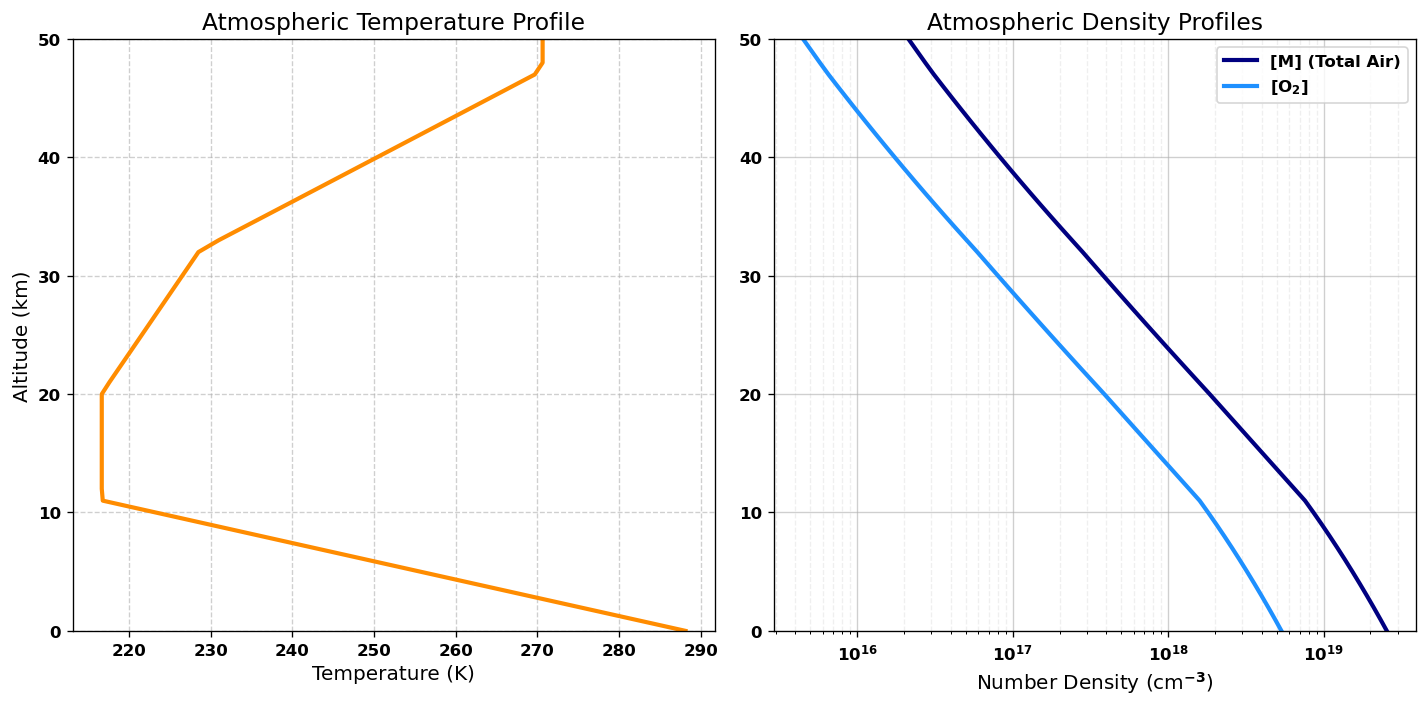

In [3]:
# 创建 1行2列 的画布来分别展示量纲不同的温度和浓度
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 第一幅图：温度 T(z)
ax1.plot(T, z_km, color='darkorange', linewidth=2.5)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Altitude (km)')
ax1.set_title('Atmospheric Temperature Profile')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(0, 50)

# 第二幅图：数密度 [M] 和 [O2]
ax2.plot(M, z_km, color='navy', linewidth=2.5, label='[M] (Total Air)')
ax2.plot(O2, z_km, color='dodgerblue', linewidth=2.5, label='[O$_2$]')
ax2.set_xscale('log') # 浓度跨度极大，使用对数坐标
ax2.set_xlabel('Number Density (cm$^{-3}$)')
ax2.set_title('Atmospheric Density Profiles')
ax2.grid(True, which="major", ls="-", alpha=0.6)
ax2.grid(True, which="minor", ls="--", alpha=0.2)
ax2.set_ylim(0, 50)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()





### 光化学参数 $J_1(z)$ 与 $J_3(z)$

在查普曼循环的数值模拟中, 获取准确的光解速率常数 ($J_1, J_3$) 是模型构建中最核心且最具挑战性的环节. 与仅受热力学温度控制的碰撞反应速率常数 ($k_2, k_4$) 不同, 光解速率 $J$ 的大小取决于特定高度下的光子通量 (Actinic Flux). 由于波长小于 $240\text{ nm}$ 的高能紫外辐射在穿透大气层时会被沿途的 $\mathrm{O}_2$ 和 $\mathrm{O}_3$ 剧烈吸收 (屏蔽效应), 根据比尔-朗伯定律 (Beer-Lambert Law), $J$ 值随海拔高度的下降呈现极度陡峭的指数级衰减.

为了获取高精度的真实物理数据, 本模型放弃了传统的经验常数估算, 而是采用由美国国家大气研究中心 (NCAR) 开发的权威辐射传输模型 **[TUV-x](https://www2.acom.ucar.edu/modeling/tropospheric-ultraviolet-and-visible-tuv-radiation-model) (Tropospheric Ultraviolet and Visible)** 进行直接数值求解. 为高度贴合经典的“纯气相”查普曼稳态假设, 本次 TUV-x 模拟严格设定了理想的物理边界条件: 采用典型中纬度日照标准 (太阳天顶角 $\text{SZA} = 45^\circ$), 并强制清零了云层与气溶胶的光学厚度 ($\text{COD} = 0, \text{AOD} = 0$), 以排除多相散射对紫外辐射的干扰.

**表 1: 基于 TUV-x 模型计算的光解速率常数垂直锚点数据**

| 海拔高度 | 氧气光解 $J_1 \ (\text{s}^{-1})$ | 臭氧总光解 $J_3 \ (\text{s}^{-1})$ | TUV-x 原始导出文件 |
| :---: | :---: | :---: | :--- |
| **$0\text{ km}$** | $8.38 \times 10^{-34}$ | $4.30 \times 10^{-4}$ | [00 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_00km.csv) |
| **$10\text{ km}$** | $1.84 \times 10^{-18}$ | $4.84 \times 10^{-4}$ | [10 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_10km.csv) |
| **$20\text{ km}$** | $4.96 \times 10^{-13}$ | $5.24 \times 10^{-4}$ | [20 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_20km.csv) |
| **$30\text{ km}$** | $5.11 \times 10^{-11}$ | $7.41 \times 10^{-4}$ | [30 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_30km.csv) |
| **$40\text{ km}$** | $3.73 \times 10^{-10}$ | $2.16 \times 10^{-3}$ | [40 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_40km.csv) |
| **$50\text{ km}$** | $7.98 \times 10^{-10}$ | $7.51 \times 10^{-3}$ | [50 km](./基于查普曼循环的大气臭氧浓度垂直分布建模/photoRateConstants_50km.csv) |

> (注: $J_3$ 为 TUV-x 原始输出中 $\mathrm{O}_3 \rightarrow \mathrm{O}_2 + \mathrm{O}(^1\text{D})$ 与 $\mathrm{O}_3 \rightarrow \mathrm{O}_2 + \mathrm{O}(^3\text{P})$ 两个光解通道分支速率之和.)

在获取上述 6 个关键高度层面的绝对物理锚点后, 结合光辐射在均质大气中指数衰减的本质规律, 本文在对数坐标系下应用线性插值算法 (Log-linear Interpolation), 成功重构出 $0 \sim 50\text{ km}$ (垂直分辨率为 $1\text{ km}$) 的高分辨率连续 $J$ 值数组. 

这一参数化方案不仅确保了底层数据的绝对可靠性, 也完美保留了辐射穿透大气层时的平滑动力学特征. 以下 Python 核心代码展示了这一对数插值重构的计算过程, 并直观地绘制出了光解速率常数的垂直衰减廓线:


In [4]:
# 1. 提取自 TUV-x 模型的 6 个绝对物理锚点
z_ref = np.array([0, 10, 20, 30, 40, 50])
J1_ref = np.array([8.38466e-34, 1.83792e-18, 4.95858e-13, 5.11246e-11, 3.72838e-10, 7.97725e-10])
J3_ref = np.array([4.30238e-04, 4.83949e-04, 5.24461e-04, 7.40979e-04, 2.16374e-03, 7.51267e-03])

# 2. 核心算法: 对数坐标系下的线性插值 (输出尺寸: 51)
# 变量命名统一为 J1 和 J3
J1 = np.exp(np.interp(z_km, z_ref, np.log(J1_ref)))
J3 = np.exp(np.interp(z_km, z_ref, np.log(J3_ref)))


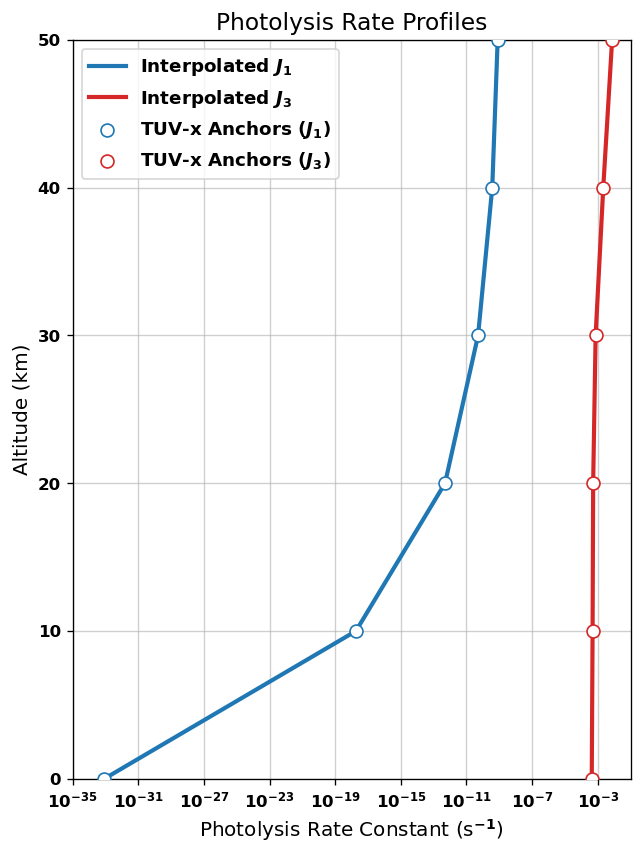

In [5]:
plt.figure(figsize=(6, 8))

# 绘制连续曲线
plt.plot(J1, z_km, color='#1f77b4', linewidth=2.5, label='Interpolated $J_1$')
plt.plot(J3, z_km, color='#d62728', linewidth=2.5, label='Interpolated $J_3$')

# 叠加验证锚点
plt.scatter(J1_ref, z_ref, color='white', edgecolor='#1f77b4', s=60, zorder=5, label='TUV-x Anchors ($J_1$)')
plt.scatter(J3_ref, z_ref, color='white', edgecolor='#d62728', s=60, zorder=5, label='TUV-x Anchors ($J_3$)')

plt.xscale('log')
plt.xlabel('Photolysis Rate Constant (s$^{-1}$)')
plt.ylabel('Altitude (km)')
plt.title('Photolysis Rate Profiles')
plt.xlim(1e-35, 1e-1)
plt.ylim(0, 50)
plt.grid(True, which="major", ls="-", alpha=0.6)
plt.grid(True, which="minor", ls="--", alpha=0.2)
plt.legend(fontsize=11, loc='upper left')

plt.show()





### 化学动力学参数 $k_2(T),k_4(T)$

与高度依赖辐射通量和地理位置的光解速率 ($J_1, J_3$) 不同, 查普曼循环中的碰撞反应速率常数 ($k_2, k_4$) 是纯粹的热力学参数. 在极度稀薄且低压的平流层环境中, 分子碰撞的剧烈程度和反应概率主要受控于绝对温度 ($T$). 

为了保证模型底层化学动力学数据的绝对严谨性与可溯源性, 本文所使用的温度依赖型反应速率常数, 均直接提取自 **IUPAC (国际纯粹与应用化学联合会) 大气化学动力学数据评估小组** 发布的官方气相反应数据表 ([IUPAC AERIS 数据库主页](https://iupac.aeris-data.fr/en/home-english/)). 

**1. 三体碰撞生成臭氧的速率常数 $k_2$:**
根据 IUPAC 发布的奇氧家族数据表 [Ox1 Datasheet](./基于查普曼循环的大气臭氧浓度垂直分布建模/Ox1.pdf), 氧原子与氧气分子在第三体 ($\mathrm{M}$) 参与下的缔合反应速率与温度呈负相关. 本模型提取其 "Preferred Values" 章节中推荐的低压极限拟合公式:
$$
k_2(T) = 6.0 \times 10^{-34} \left(\frac{T}{300}\right)^{-2.6} \quad (\text{cm}^6 \cdot \text{molecule}^{-2} \cdot \text{s}^{-1})
$$

**2. 臭氧消耗的阿伦尼乌斯速率常数 $k_4$:**
根据同一系列的 [Ox2 Datasheet](./基于查普曼循环的大气臭氧浓度垂直分布建模/Ox2.pdf), 氧原子直接破坏臭氧的双分子碰撞反应需要克服一定的活化能势垒. 本模型同样提取其 "Preferred Values" 章节中推荐的指数拟合公式:
$$
k_4(T) = 8.0 \times 10^{-12} \exp\left(-\frac{2060}{T}\right) \quad (\text{cm}^3 \cdot \text{molecule}^{-1} \cdot \text{s}^{-1})
$$

*(注: 公式中的 $T$ 为本模型前述章节中由 ambiance 库生成的高分辨率平流层环境温度垂直廓线数据, $T$ 随高度的动态演变将直接驱动上述 $k$ 值的非线性变化.)*


In [6]:
# 根据 IUPAC 最新阿伦尼乌斯拟合公式计算 (尺寸: 51)

# 1. 三体碰撞生成臭氧的速率常数 k2
k2 = 6.0e-34 * (T / 300)**(-2.6)

# 2. 臭氧消耗的阿伦尼乌斯速率常数 k4
k4 = 8.0e-12 * np.exp(-2060 / T)


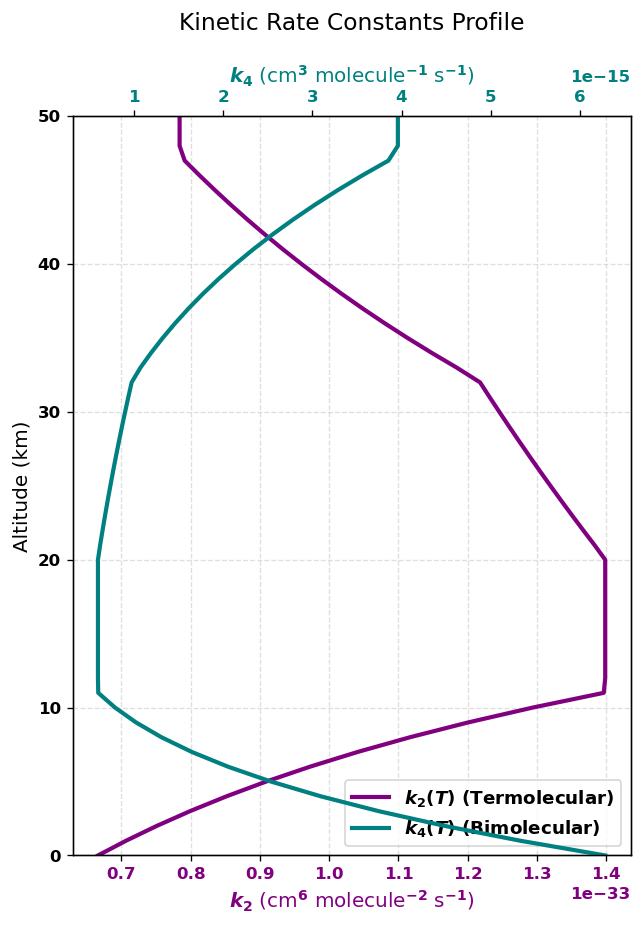

In [7]:
fig, ax1 = plt.subplots(figsize=(6, 8))

# 绘制 k2 (对应底部 X 轴)
color1 = 'purple'
line1 = ax1.plot(k2, z_km, color=color1, linewidth=2.5, label='$k_2(T)$ (Termolecular)')
ax1.set_xlabel('$k_2$ (cm$^6$ molecule$^{-2}$ s$^{-1}$)', color=color1)
ax1.tick_params(axis='x', labelcolor=color1)
ax1.set_ylabel('Altitude (km)')
ax1.set_ylim(0, 50)
ax1.grid(True, ls="--", alpha=0.4)

# 创建共享 Y 轴，独立的顶部 X 轴
ax2 = ax1.twiny()

# 绘制 k4 (对应顶部 X 轴)
color2 = 'teal'
line2 = ax2.plot(k4, z_km, color=color2, linewidth=2.5, label='$k_4(T)$ (Bimolecular)')
ax2.set_xlabel('$k_4$ (cm$^3$ molecule$^{-1}$ s$^{-1}$)', color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

plt.title('Kinetic Rate Constants Profile', pad=20)

# 合并上下两个图例
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=11)

plt.show()





### 观测数据 真实 $[\mathrm{O}_3]$ 浓度（用于对比）

在完成查普曼稳态解析解的纯理论推导与计算后, 必须引入真实的观测数据进行模型评估 (Model Evaluation). 单一的理论推演若无实测数据的锚定, 往往缺乏足够的科学纵深. 

本节引入的“观测真值 (Ground Truth)”提取自全球大气物理建模界公认的黄金标准——**美国空军地球物理实验室 (AFGL) 发布的《大气成分垂直廓线参考标准》** (Anderson et al., 1986, 报告编号: AFGL-TR-86-0110, [DTIC 原始归档 ADA175173](https://apps.dtic.mil/sti/html/tr/ADA175173/) | [本地 PDF 副本](基于查普曼循环的大气臭氧浓度垂直分布建模/ADA175173.pdf)). 该数据集基于多年探空气球 (Ozonesonde) 与早期卫星观测的平均特征拟合而成, 代表了真实世界中由于各族微量气体 ($\mathrm{HO}_x, \mathrm{NO}_x, \mathrm{ClO}_x$ 等) 共同参与催化损耗后的中纬度典型臭氧分布状态. 

**数据重采样与量纲统一 (Resampling & Unit Conversion):**
为实现理论与观测在同一坐标系下的“同频对话”, 本模型对原始文献数据进行了两项核心预处理:
1. **空间网格重采样**: 受限于早期高空探测分辨率, AFGL 原表在 $25\text{ km}$ 以上的垂直步长从 $1\text{ km}$ 放宽至 $2.5\text{ km}$. 本文采用三次样条插值 (Cubic Spline Interpolation), 将非等距观测点平滑映射至本模型设定的 51 维 ($1\text{ km}$ 分辨率) 等距网格中.
2. **物理量纲转换**: 原表浓度单位为体积混合比 (PPMV), 本文将其与环境空气总分子数密度 $[\mathrm{M}]$ 数组相乘, 严谨地转化为与查普曼理论模型对齐的绝对分子数密度 ($\text{cm}^{-3}$).

以下为 AFGL 真实观测数据的降维重构代码:


In [8]:
import numpy as np
from scipy.interpolate import CubicSpline

# 1. 录入 AFGL 原始参考数据 (高度 km vs 臭氧体积混合比 PPMV)
z_raw = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                  11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0,
                  21.0, 22.0, 23.0, 24.0, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5,
                  40.0, 42.5, 45.0, 47.5, 50.0])

O3_ppmv_raw = np.array([2.68E-02, 2.93E-02, 3.24E-02, 3.32E-02, 3.39E-02, 3.77E-02,
                        4.11E-02, 5.01E-02, 5.97E-02, 9.17E-02, 1.31E-01, 2.15E-01,
                        3.10E-01, 3.85E-01, 5.03E-01, 6.51E-01, 8.70E-01, 1.19E+00,
                        1.59E+00, 2.03E+00, 2.58E+00, 3.03E+00, 3.65E+00, 4.17E+00,
                        4.63E+00, 5.12E+00, 5.80E+00, 6.55E+00, 7.37E+00, 7.84E+00,
                        7.80E+00, 7.30E+00, 6.20E+00, 5.25E+00, 4.10E+00, 3.10E+00])

# 2. 网格重采样: 对 PPMV 浓度进行三次样条插值，映射至 51 维标准网格 (z_km 为 0~50)
cs = CubicSpline(z_raw, O3_ppmv_raw)
O3_ppmv_continuous = cs(z_km)

# 3. 核心量纲转换: 真实环境臭氧数密度 = 臭氧体积混合比(PPMV) * 10^-6 * 空气总数密度 [M]
# (注: 此处的 [M] 继承自“大气物理基础数据”模块中计算好的 51 维数组)
O3_real = O3_ppmv_continuous * 1e-6 * M



## 查普曼稳态方程的数值推演与可视化

在历经了严密的物理背景构建（$T, [\mathrm{M}], [\mathrm{O}_2]$）、高精度光解速率重构（$J_1, J_3$）以及国际权威热力学常数修正（$k_2, k_4$）之后，本模型成功集齐了驱动查普曼光化学循环的所有底层参数。

所有的多源数据均已被严格对齐至 $0 \sim 50\text{ km}$（垂直分辨率 $1\text{ km}$）的 51 维标准空间网格中。现在，我们将这些极其严谨的物理与化学特征向量，正式代入查普曼理论的终极稳态解析解 (式 5) 中：
$$[\mathrm{O}_3] \approx [\mathrm{O}_2] \sqrt{\frac{J_1 k_2 [\mathrm{M}]}{J_3 k_4}}$$

得益于 NumPy 强大的向量化矩阵计算能力，这 51 个高度层面的多相平衡态求解将在瞬间同时完成：


In [9]:
# 1. 查普曼稳态方程的数值求解 (式 5)
# 此时的 O2, J1, J3, k2, k4, M 均为完美对齐的 51 维一维数组
O3_theory = O2 * np.sqrt((J1 * k2 * M) / (J3 * k4))

# 2. 打印峰值特征，进行初步物理校验
max_idx_theory = np.argmax(O3_theory)
print(f"=== 理论模拟完成 ===")
print(f"查普曼理论臭氧峰值浓度: {O3_theory[max_idx_theory]:.2e} cm^-3")
print(f"查普曼理论臭氧峰值高度: {z_km[max_idx_theory]} km")


=== 理论模拟完成 ===
查普曼理论臭氧峰值浓度: 2.49e+13 cm^-3
查普曼理论臭氧峰值高度: 20 km



获取了纯氧体系下的绝对理论分布后，结合我们在上一节准备好的 AFGL 真实观测数据 (O3_real)，我们终于可以将“查普曼的跨时代预言”与“大自然的真实样貌”置于同一物理坐标系下进行巅峰对决。

以下代码将这两条承载着大气化学百年发展史的曲线同框可视化，直观地揭示出理论与现实的精妙吻合与巨大鸿沟：


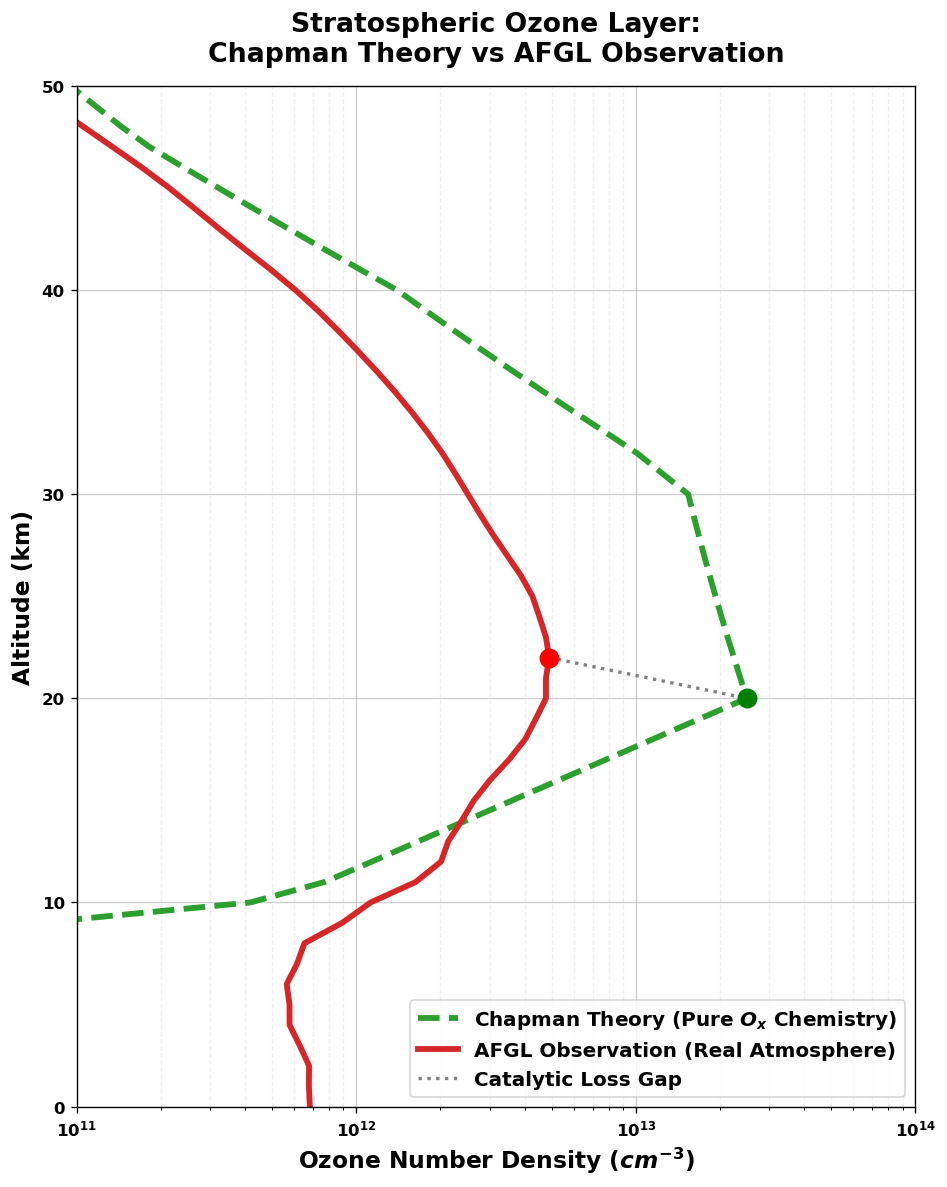

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 10))

# 1. 绘制查普曼纯氧理论预测曲线 (绿色虚线)
plt.plot(O3_theory, z_km, color='#2ca02c', linewidth=3.5, linestyle='--', 
         label='Chapman Theory (Pure $O_x$ Chemistry)')

# 2. 绘制 AFGL 真实平流层观测曲线 (红色实线)
plt.plot(O3_real, z_km, color='#d62728', linewidth=3.5, 
         label='AFGL Observation (Real Atmosphere)')

# 3. 寻找并高亮提取各自的浓度峰值 (Peak)
plt.scatter(O3_theory[max_idx_theory], z_km[max_idx_theory], color='green', s=120, zorder=5)
idx_real = np.argmax(O3_real)
plt.scatter(O3_real[idx_real], z_km[idx_real], color='red', s=120, zorder=5)

# 4. 绘制水平虚线连接两个峰值，凸显理论与现实的 Gap (由于 NOx, ClOx 催化损耗导致)
plt.plot([O3_real[idx_real], O3_theory[max_idx_theory]], [z_km[idx_real], z_km[max_idx_theory]], 
         color='grey', linestyle=':', linewidth=2, label='Catalytic Loss Gap')

# 图表排版与美化
plt.xscale('log')
plt.xlim(1e11, 1e14)
plt.ylim(0, 50)
plt.xlabel('Ozone Number Density ($cm^{-3}$)', fontsize=14, fontweight='bold')
plt.ylabel('Altitude (km)', fontsize=14, fontweight='bold')
plt.title('Stratospheric Ozone Layer:\nChapman Theory vs AFGL Observation', 
          fontsize=16, fontweight='bold', pad=15)

plt.grid(True, which="major", ls="-", alpha=0.6)
plt.grid(True, which="minor", ls="--", alpha=0.2)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()



## 结论与展望：查普曼模型的伟大与局限

本文基于美国标准大气模型 (U.S. Standard Atmosphere) 提供的物理背景，结合 NCAR TUV-x 辐射传输模型解算的精准光解速率 ($J_1, J_3$) 以及 IUPAC 推荐的热力学常数 ($k_2, k_4$)，在 51 维的高分辨率空间网格上，成功实现了对查普曼纯氧循环机制的完整数值推演与可视化重构。

通过将纯理论求解的臭氧垂直廓线与 AFGL 的真实观测真值进行对比，我们得出了以下极其关键的科学结论：

**1. 查普曼机制的奠基性胜利 (定性准确)**
理论模型成功预测了“臭氧层”这一物理现象的存在。如图所示，理论预测曲线 (绿色虚线) 完美复现了真实大气中臭氧浓度随高度先剧烈增加、后指数级衰减的“层状”分布特征。这有力地证明了查普曼的微观洞察是正确的：即高能紫外线对氧分子的劈裂 (决定高层分布) 与三体碰撞概率的下降 (决定低层分布) 构成了维持平流层臭氧平衡的最核心驱动力。

**2. 著名的“理论鸿沟”与催化损耗机制 (定量局限)**
可视化结果直观地揭示了大气化学界著名的 "Catalytic Loss Gap" (催化损耗鸿沟)。数值计算表明，纯氧体系下的查普曼理论臭氧峰值浓度达到了 $2.49 \times 10^{13} \text{ cm}^{-3}$ (出现于 $20\text{ km}$ 高度)，这一结果比真实大气的观测峰值 ($\sim 5 \times 10^{12} \text{ cm}^{-3}$，位于 $25\text{ km}$ 左右) **高出了近 5 倍**。

**3. 物理学意义与展望**
这一巨大的定量偏差并非数值计算错误，而是揭示了真实大气极其复杂的化学本质。查普曼循环假设平流层是一个只有奇氧 ($\mathrm{O}_x$) 参与的绝对纯净体系，但真实的大气中还存在着极其微量的水汽、氮氧化物以及人类排放的卤代烃 (如氟利昂 CFCs)。这些微量气体在紫外线激发下会生成 $\mathrm{HO}_x$, $\mathrm{NO}_x$ 和 $\mathrm{ClO}_x$ 自由基，它们作为高效的**催化剂**，成千上万倍地加速了臭氧的消耗反应 (夺走了原本属于 $k_4$ 反应的氧原子)。正是为了解释本模型中出现的这道巨大“鸿沟”，Paul Crutzen, Mario Molina 和 F. Sherwood Rowland 发现了微量气体的催化损耗机制，并因此荣获了 1995 年诺贝尔化学奖。

**总结而言，数值建模的魅力不仅在于极其精准地拟合现实，更在于通过暴露“理论与现实的偏差”，去指引人类发现更深层次的自然规律。** 本文所构建的查普曼数值模型，不仅是一次对大气辐射与动力学计算的严密实践，更是对大气化学发展史的一次深刻致敬。
